# CertCF Query-Norm Ablation

Reviewer-facing paired comparison of L1 and L2 CertCF query objectives on the seven tabular paper datasets. Both variants use the same L1 certified atlas configuration, queries, support sample, solver settings, and no auxiliary sparsity penalty. This notebook is intentionally separate from the published sparse-L1 benchmark.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
for path in (ROOT, ROOT / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from notebooks.utils.norm_ablation import (
    NORM_ABLATION_DATASETS,
    NORM_ABLATION_EXPECTED_TASKS,
    NORM_ABLATION_LABELS,
    NORM_ABLATION_RUNS,
    load_norm_ablation_results,
    norm_ablation_aggregate_summary,
    norm_ablation_completion_table,
    norm_ablation_dataset_summary,
    norm_ablation_paired_deltas,
    validate_norm_ablation_results,
)
from notebooks.utils.style import setup_notebook_style

setup_notebook_style()
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

RESULT_PATH = ROOT / 'results' / 'certcf_query_norm_ablation.parquet'
CONFIG_PATH = ROOT / 'configs' / 'benchmarks' / 'certcf_query_norm_ablation.yaml'
EXPORT_DIR = ROOT / 'results' / 'certcf_query_norm_ablation_analysis'
EXPECTED_TASKS_BY_DATASET = NORM_ABLATION_EXPECTED_TASKS
EXPORT_OUTPUTS = False
FIGURES = {}
print({'result': str(RESULT_PATH), 'config': str(CONFIG_PATH)})

{'result': '/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/certcf_query_norm_ablation.parquet', 'config': '/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/certcf_query_norm_ablation.yaml'}


## 1. Benchmark progress and integrity

The loader reads both the final combined parquet and any completed per-dataset files. This makes the notebook safe to open while the benchmark is still running. Final tables remain disabled until all 14 dataset/run combinations contain their paper-standard task budget: at most 1,000 queries, or the complete test split when it is smaller.

,source,path,available,readable,rows,error
0,combined,/home/gabrielepintus/Documents/github/Preimage...,True,True,9546,None
1,adult,/home/gabrielepintus/Documents/github/Preimage...,True,True,2000,None
2,compas,/home/gabrielepintus/Documents/github/Preimage...,True,True,1234,None
3,german_credit,/home/gabrielepintus/Documents/github/Preimage...,True,True,200,None
4,give_me_some_credit,/home/gabrielepintus/Documents/github/Preimage...,True,True,2000,None
5,heloc,/home/gabrielepintus/Documents/github/Preimage...,True,True,2000,None
6,lending_club,/home/gabrielepintus/Documents/github/Preimage...,True,True,2000,None
7,wisconsin_breast_cancer,/home/gabrielepintus/Documents/github/Preimage...,True,True,112,None


,dataset,run_name,run_label,rows,unique_tasks,successes,expected_tasks,complete
0,adult,certcf_query_l1_no_sparsity,L1 query objective,1000,1000,1000,1000,True
1,adult,certcf_query_l2_no_sparsity,L2 query objective,1000,1000,1000,1000,True
2,compas,certcf_query_l1_no_sparsity,L1 query objective,617,617,617,1000,False
3,compas,certcf_query_l2_no_sparsity,L2 query objective,617,617,617,1000,False
4,german_credit,certcf_query_l1_no_sparsity,L1 query objective,100,100,100,1000,False
5,german_credit,certcf_query_l2_no_sparsity,L2 query objective,100,100,100,1000,False
6,give_me_some_credit,certcf_query_l1_no_sparsity,L1 query objective,1000,1000,1000,1000,True
7,give_me_some_credit,certcf_query_l2_no_sparsity,L2 query objective,1000,1000,1000,1000,True
8,heloc,certcf_query_l1_no_sparsity,L1 query objective,1000,1000,1000,1000,True
9,heloc,certcf_query_l2_no_sparsity,L2 query objective,1000,1000,1000,1000,True


run_label,L1 query objective,L2 query objective
dataset,,
adult,1000,1000
compas,617,617
german_credit,100,100
give_me_some_credit,1000,1000
heloc,1000,1000
lending_club,1000,1000
wisconsin_breast_cancer,56,56


**Benchmark still running:** 8/14 dataset/run combinations are complete. Final comparisons below are intentionally withheld.

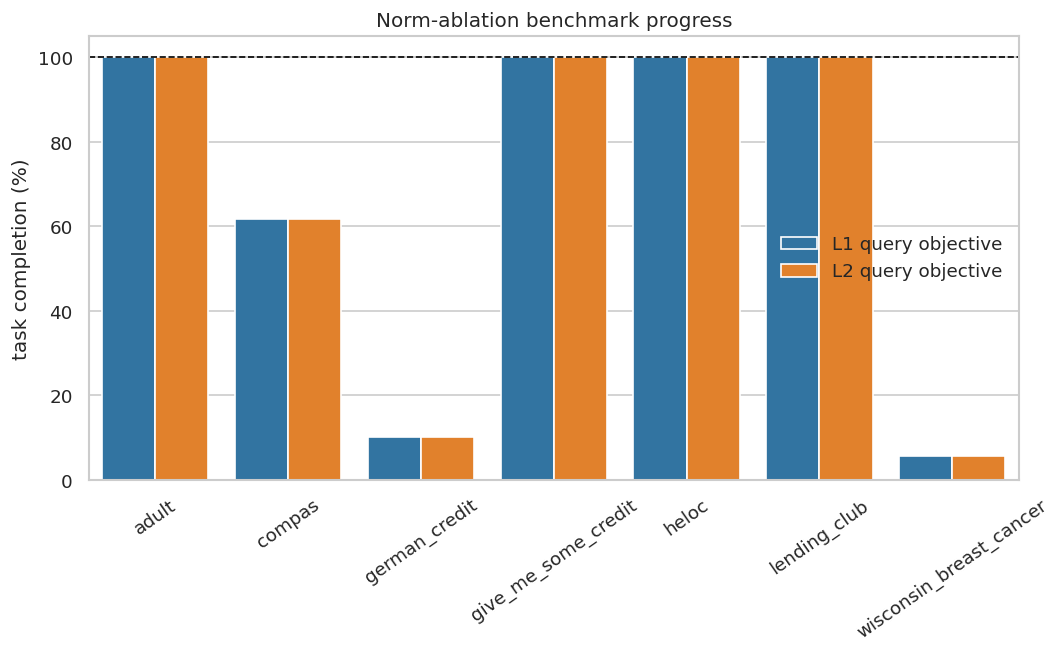

In [2]:
RESULT_DF, FILE_STATUS_DF = load_norm_ablation_results(RESULT_PATH)
COMPLETION_DF = norm_ablation_completion_table(
    RESULT_DF,
    expected_tasks=EXPECTED_TASKS_BY_DATASET,
)
IS_COMPLETE = bool(COMPLETION_DF['complete'].all())
display(FILE_STATUS_DF)
display(COMPLETION_DF)

completion_pivot = COMPLETION_DF.pivot(index='dataset', columns='run_label', values='unique_tasks')
display(completion_pivot)
if IS_COMPLETE:
    display(Markdown('**Benchmark complete:** all seven datasets and both query norms contain their expected matched task sets.'))
else:
    completed = int(COMPLETION_DF['complete'].sum())
    display(Markdown(f'**Benchmark still running:** {completed}/14 dataset/run combinations are complete. Final comparisons below are intentionally withheld.'))

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_progress = COMPLETION_DF.copy()
plot_progress['completion_pct'] = 100.0 * plot_progress['unique_tasks'] / plot_progress['expected_tasks']
sns.barplot(data=plot_progress, x='dataset', y='completion_pct', hue='run_label', ax=ax)
ax.axhline(100.0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(0, 105)
ax.set_ylabel('task completion (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
ax.set_title('Norm-ablation benchmark progress')
ax.legend(title='', frameon=False)
FIGURES['completion'] = fig
plt.show()

In [3]:
if not RESULT_DF.empty:
    PARAMETER_AUDIT_DF = (
        RESULT_DF.groupby(['dataset', 'run_name'], observed=True)
        .agg(
            rows=('query_idx', 'size'),
            distance_norm=('meta__distance_norm', 'first'),
            sparsity_penalty=('meta__sparsity_penalty', 'first'),
            build_time_s=('build_time_s', 'first'),
        )
        .reset_index()
    )
else:
    PARAMETER_AUDIT_DF = pd.DataFrame()
display(PARAMETER_AUDIT_DF)

if IS_COMPLETE:
    validate_norm_ablation_results(
        RESULT_DF,
        expected_tasks=EXPECTED_TASKS_BY_DATASET,
    )
    print('Strict validation passed: task sets match and only distance_norm differs.')

,dataset,run_name,rows,distance_norm,sparsity_penalty,build_time_s
0,adult,certcf_query_l1_no_sparsity,1000,1,none,30.754715
1,adult,certcf_query_l2_no_sparsity,1000,2,none,30.892265
2,compas,certcf_query_l1_no_sparsity,617,1,none,14.603861
3,compas,certcf_query_l2_no_sparsity,617,2,none,14.566830
4,german_credit,certcf_query_l1_no_sparsity,100,1,none,22.950292
5,german_credit,certcf_query_l2_no_sparsity,100,2,none,22.962197
6,give_me_some_credit,certcf_query_l1_no_sparsity,1000,1,none,25.412312
7,give_me_some_credit,certcf_query_l2_no_sparsity,1000,2,none,25.601419
8,heloc,certcf_query_l1_no_sparsity,1000,1,none,32.334116
9,heloc,certcf_query_l2_no_sparsity,1000,2,none,31.515238


## 2. Evaluation protocol

- Validity is evaluated on the full paper-standard task set per dataset and norm: up to 1,000 queries, capped by test-split size.
- L1, L2, and L0 quality are evaluated on the shared-success subset, preventing differential failures from biasing proximity.
- Query time is summarized over all attempted tasks and also paired on shared successes for delta plots.
- L0 count is reconstructed as `l0_sparsity × encoded feature dimension`.
- Build time is shown only as an execution audit. It is not interpreted as an effect of the query norm because the current runner rebuilds otherwise identical atlases.

In [4]:
if IS_COMPLETE:
    DATASET_SUMMARY_DF = norm_ablation_dataset_summary(RESULT_DF)
    AGGREGATE_SUMMARY_DF = norm_ablation_aggregate_summary(DATASET_SUMMARY_DF)
    QUERY_DELTAS_DF, DATASET_DELTAS_DF = norm_ablation_paired_deltas(RESULT_DF)
    delta_columns = [column for column in DATASET_DELTAS_DF if column != 'dataset']
    DELTA_AGGREGATE_DF = pd.DataFrame({
        'metric': delta_columns,
        'dataset_mean': [DATASET_DELTAS_DF[column].mean() for column in delta_columns],
        'dataset_std': [DATASET_DELTAS_DF[column].std(ddof=1) for column in delta_columns],
    })
else:
    DATASET_SUMMARY_DF = pd.DataFrame()
    AGGREGATE_SUMMARY_DF = pd.DataFrame()
    QUERY_DELTAS_DF = pd.DataFrame()
    DATASET_DELTAS_DF = pd.DataFrame()
    DELTA_AGGREGATE_DF = pd.DataFrame()

if IS_COMPLETE:
    display(DATASET_SUMMARY_DF.round(5))
    display(DATASET_DELTAS_DF.round(5))
    display(DELTA_AGGREGATE_DF.round(5))

## 3. Reviewer-facing aggregate table

Each entry is the mean ± sample standard deviation of the seven dataset-level values. No comparison is made against the published reweighted-L1 run because that would confound the query norm with the auxiliary sparsity objective.

In [5]:
def mean_std_text(row, metric, digits):
    return f"{row[f'{metric}_mean']:.{digits}f} ± {row[f'{metric}_std']:.{digits}f}"

if IS_COMPLETE:
    reviewer_rows = []
    for _, row in AGGREGATE_SUMMARY_DF.iterrows():
        reviewer_rows.append({
            'Query objective': row['run_label'],
            'Validity (%)': mean_std_text(row, 'validity_pct', 2),
            'L1 distance': mean_std_text(row, 'l1_mean', 3),
            'L2 distance': mean_std_text(row, 'l2_mean', 3),
            'Changed features': mean_std_text(row, 'l0_count_mean', 3),
            'Changed fraction': mean_std_text(row, 'l0_fraction_mean', 3),
            'Mean query time (s)': mean_std_text(row, 'query_time_mean_s', 4),
            'Median query time (s)': mean_std_text(row, 'query_time_median_s', 4),
        })
    REVIEWER_TABLE_DF = pd.DataFrame(reviewer_rows)
    display(REVIEWER_TABLE_DF)
else:
    REVIEWER_TABLE_DF = pd.DataFrame()
    display(Markdown('Reviewer table will be generated automatically when the benchmark is complete.'))

Reviewer table will be generated automatically when the benchmark is complete.

## 4. Per-dataset comparisons

In [6]:
if IS_COMPLETE:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    plot_specs = [
        ('validity_pct', 'Validity (%)', axes[0, 0]),
        ('l1_mean', 'Mean L1 on shared successes', axes[0, 1]),
        ('l2_mean', 'Mean L2 on shared successes', axes[1, 0]),
        ('l0_count_mean', 'Mean changed-feature count', axes[1, 1]),
    ]
    for metric, title, ax in plot_specs:
        sns.barplot(data=DATASET_SUMMARY_DF, x='dataset', y=metric, hue='run_label', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=35)
        if ax is not axes[0, 0]:
            ax.get_legend().remove()
    axes[0, 0].legend(title='', frameon=False, fontsize=8)
    FIGURES['per_dataset_metrics'] = fig
    plt.show()
else:
    print('Per-dataset plots withheld until completion.')

Per-dataset plots withheld until completion.


## 5. Paired L2-minus-L1 effects

Negative values favor L2 for a metric that should be minimized. In particular, the expected signature is a negative L2-distance delta and a positive changed-feature delta; the notebook does not assume that result in advance.

In [7]:
if IS_COMPLETE:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    delta_specs = [
        ('l1_distance_delta_l2_minus_l1', 'Δ L1 distance'),
        ('l2_distance_delta_l2_minus_l1', 'Δ L2 distance'),
        ('l0_count_delta_l2_minus_l1', 'Δ changed features'),
        ('runtime_s_delta_l2_minus_l1', 'Δ query time (s)'),
    ]
    for ax, (metric, title) in zip(axes.ravel(), delta_specs):
        sns.boxplot(data=QUERY_DELTAS_DF, x='dataset', y=metric, showfliers=False, ax=ax)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{title}: L2 − L1')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=35)
    FIGURES['paired_deltas'] = fig
    plt.show()
else:
    print('Paired-delta plots withheld until completion.')

Paired-delta plots withheld until completion.


## 6. LaTeX and optional export

In [8]:
if IS_COMPLETE:
    REVIEWER_TABLE_LATEX = REVIEWER_TABLE_DF.to_latex(index=False, escape=False)
    print(REVIEWER_TABLE_LATEX)
else:
    REVIEWER_TABLE_LATEX = ''

if EXPORT_OUTPUTS and IS_COMPLETE:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    DATASET_SUMMARY_DF.to_csv(EXPORT_DIR / 'per_dataset_metrics.csv', index=False)
    AGGREGATE_SUMMARY_DF.to_csv(EXPORT_DIR / 'aggregate_metrics.csv', index=False)
    DATASET_DELTAS_DF.to_csv(EXPORT_DIR / 'per_dataset_paired_deltas.csv', index=False)
    DELTA_AGGREGATE_DF.to_csv(EXPORT_DIR / 'aggregate_paired_deltas.csv', index=False)
    REVIEWER_TABLE_DF.to_csv(EXPORT_DIR / 'reviewer_table.csv', index=False)
    (EXPORT_DIR / 'reviewer_table.tex').write_text(REVIEWER_TABLE_LATEX + '\n', encoding='utf-8')
    for name, fig in FIGURES.items():
        if name == 'completion':
            continue
        fig.savefig(EXPORT_DIR / f'{name}.png', dpi=200, bbox_inches='tight')
        fig.savefig(EXPORT_DIR / f'{name}.pdf', bbox_inches='tight')
    print(f'Exported completed analysis to {EXPORT_DIR}')
elif EXPORT_OUTPUTS:
    print('EXPORT_OUTPUTS=True, but export is blocked until all runs are complete.')
else:
    print('EXPORT_OUTPUTS=False; no final artifacts written.')

EXPORT_OUTPUTS=False; no final artifacts written.
